# Ocean Stratification — GLORYS 3D

Tour of the *vertical-structure* transformations in `xrtoolz.ocn`. Where the kinematics notebook is purely 2-D-horizontal, this one walks down the water column: density, Brunt-Väisälä, mixed-layer depth, lapse rate, advection, and barotropic PV. We use the GLORYS12 3D cache (5 days, 22 vertical levels from ~0.5 m to ~92 m, Gulf Stream box at 1/12°). DUACS does not enter — altimetry sees only the surface and so cannot resolve any of the diagnostics here.

Each diagnostic gets the same five-part block as the other ocean notebooks: ELI5 → formal definition → continuous equation → discretisation → interpretation. Bonus sections at the end show the same diagnostics composed via `Sequential` and `Graph`.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

# Silence third-party deprecation noise that clutters the rendered notebook.
warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from xrtoolz import Augment, Graph, Input, Sequential, Signature
from xrtoolz.ocn.operators import (
    Advection,
    BruntVaisalaFrequency,
    LapseRate,
    MixedLayerDepth,
    PotentialVorticityBarotropic,
)

GLORYS_CACHE = Path("../../.cache/glorys12_3d_gulfstream_2023-06.nc")

## 1 — Load GLORYS 3D

Same cache as the V4 process-evaluation notebook: 22 depth levels, 5 days, full Gulf Stream box. We resnap lat/lon to the nearest uniform spacing (the raw netCDF carries float32 wobble that breaks uniform-grid checks downstream).

In [2]:
ds = (
    xr.open_dataset(GLORYS_CACHE)
    .rename({"latitude": "lat", "longitude": "lon"})
)
ds = ds.assign_coords(
    lat=("lat", np.linspace(float(ds.lat[0]), float(ds.lat[-1]), ds.sizes["lat"]),
         {"units": "degrees_north"}),
    lon=("lon", np.linspace(float(ds.lon[0]), float(ds.lon[-1]), ds.sizes["lon"]),
         {"units": "degrees_east"}),
)
print("GLORYS:", dict(ds.sizes), list(ds.data_vars))
print(f"depth range: {float(ds.depth.min()):.1f} → {float(ds.depth.max()):.1f} m, "
      f"{ds.sizes['depth']} levels")

GLORYS: {'time': 5, 'depth': 22, 'lat': 181, 'lon': 241} ['uo', 'vo', 'thetao', 'so', 'zos']
depth range: 0.5 → 92.3 m, 22 levels


We work on the time-mean state for clarity, and we'll also need a single profile
(one lat/lon column) for the per-quantity vertical figures.

In [3]:
ds_t = ds.mean(dim="time")
profile_lat, profile_lon = 38.0, -65.0  # Gulf Stream front, deep water
profile = ds_t.sel(lat=profile_lat, lon=profile_lon, method="nearest")
print(f"profile column at ({profile_lat}°N, {profile_lon}°E): "
      f"{profile.sizes['depth']} samples")


def latdepth_section(da, *, lon=-65.0, title, cmap="viridis", vlim=None, center_zero=False):
    """Lat-depth section at fixed longitude."""
    section = da.sel(lon=lon, method="nearest")
    fig, ax = plt.subplots(figsize=(8.5, 3.6), constrained_layout=True)
    if vlim is None:
        v = float(np.nanmax(np.abs(section.values)))
        vlim = (-v, v) if center_zero else (float(np.nanmin(section.values)), v)
    im = ax.pcolormesh(section["lat"], section["depth"], section.values, vmin=vlim[0], vmax=vlim[1], cmap=cmap)
    ax.invert_yaxis()
    ax.set_xlabel("Latitude (°N)")
    ax.set_ylabel("Depth (m)")
    ax.set_title(f"{title} — lon = {float(section['lon']):.1f}°", fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    plt.show()


def surface_map(da, *, title, cmap="viridis", vlim=None, center_zero=False):
    """Top-depth map for fields with a vertical dim, or any 2-D field."""
    if "depth" in da.dims:
        da = da.isel(depth=0)
    fig, ax = plt.subplots(figsize=(7.5, 3.6), constrained_layout=True)
    if vlim is None:
        v = float(np.nanmax(np.abs(da.values)))
        vlim = (-v, v) if center_zero else (float(np.nanmin(da.values)), v)
    im = ax.pcolormesh(da["lon"], da["lat"], da.values, vmin=vlim[0], vmax=vlim[1], cmap=cmap)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    plt.show()

profile column at (38.0°N, -65.0°E): 22 samples


## 2 — Numerical preamble: vertical operators

Stratification is a story about the **vertical** axis. Three things change relative to the kinematics notebook:

- **Vertical derivatives**: `xrtoolz.calc.partial(da, "depth", geometry="cartesian")` runs second-order central FD on whatever the depth coord is (here metres). Edge cells fall back to one-sided differences.
- **Sign convention**: GLORYS depth increases downward (`positive="down"`). The `BruntVaisalaFrequency` and `LapseRate` operators take a `positive=` kwarg so $-\partial \rho / \partial z$ has the conventional sign regardless of how the input dataset is oriented.
- **Equation of state**: density depends on temperature, salinity, and pressure. The full TEOS-10 EOS lives in the optional `gsw` dependency (`xrtoolz.ocn.density_from_ts`); when it isn't available we fall back to a **linear EOS** $\rho \approx \rho_0(1 - \alpha\,\theta + \beta\,S)$. The linear approximation is good enough for the structure-level diagnostics below — but if you actually need water masses, install `xrtoolz[oceanography]` for `gsw`.

## 3 — Density from temperature and salinity

**ELI5.** Cold, salty water is denser than warm, fresh water. Density tells you which water sits on top of which.

**What it is.** The volumetric mass density of seawater $\rho(\theta, S, p)$ in kg/m³. Drives every buoyancy-related dynamics: stratification, gravity waves, deep convection, overturning circulation. The full nonlinear equation of state (TEOS-10) accounts for temperature, salinity, *and* pressure; a linear approximation drops the pressure dependence and replaces $\rho(\theta, S)$ with a Taylor expansion around a reference state.

**Continuous formulation.** Linear EOS:

$$
    \rho(\theta, S) \approx \rho_0\,\bigl(1 - \alpha\,\theta + \beta\,S\bigr),
$$

with $\rho_0 = 1027$ kg/m³, $\alpha = 2 \times 10^{-4}$ K⁻¹ (thermal expansion), $\beta = 7.6 \times 10^{-4}$ (psu)⁻¹ (haline contraction). The full TEOS-10 form is $\rho = \rho(S_A, \Theta, p)$ via Gibbs-function derivatives — see GSW-Python documentation for the polynomial implementation.

**Discretisation.** Pointwise — no derivatives. We multiply the linear-EOS expression elementwise and store the result under `rho`. Switching to TEOS-10 swaps the cell for a single call to `density_from_ts(ds, eos="teos10")` (gated on `gsw` being installed).

**Interpretation.** Density on the lat-depth section below shows the classic Gulf Stream **slope of isopycnals**: density surfaces tilt downward to the south, supporting an eastward thermal-wind shear. The shallowest 100 m of the section also shows the seasonal mixed layer (≈ uniform density near the surface). These slopes and steps are what every other diagnostic in this notebook quantifies in different ways.

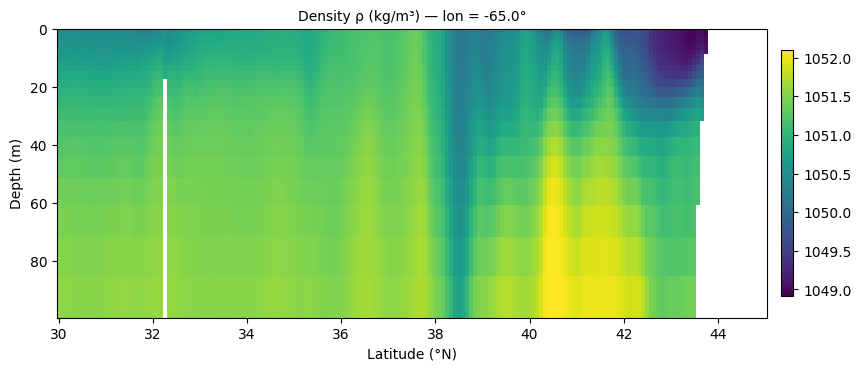

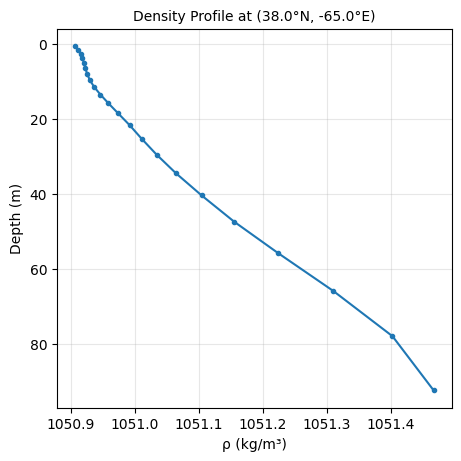

In [4]:
rho0, alpha, beta = 1027.0, 2.0e-4, 7.6e-4
ds_rho = ds_t.assign(
    rho=(rho0 * (1 - alpha * ds_t["thetao"] + beta * ds_t["so"])).assign_attrs(
        long_name="In-situ density (linear EOS)", units="kg m-3"
    ),
)
profile_rho = ds_rho.sel(lat=profile_lat, lon=profile_lon, method="nearest")

latdepth_section(ds_rho["rho"], title="Density ρ (kg/m³)", cmap="viridis")

fig, ax = plt.subplots(figsize=(4.5, 4.5), constrained_layout=True)
ax.plot(profile_rho["rho"].values, profile_rho["depth"].values, marker="o", markersize=3)
ax.invert_yaxis()
ax.set_xlabel("ρ (kg/m³)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"Density Profile at ({profile_lat}°N, {profile_lon}°E)", fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## 4 — Brunt-Väisälä frequency $N^2$

**ELI5.** Push a parcel of water upward against gravity, and let go. If the surrounding water is more buoyant, it floats back down and bobs. $N^2$ tells you how *fast* it would bob — the natural frequency of vertical oscillations driven by stratification.

**What it is.** The buoyancy frequency squared. Sets the timescale of internal gravity waves, the inhibition of vertical mixing, and the Rossby radius of deformation. Where $N^2 > 0$ the column is stably stratified; $N^2 < 0$ implies a density inversion (gravitationally unstable, will overturn).

**Continuous formulation.**

$$
    N^2(z) = -\frac{g}{\rho_0}\,\frac{\partial \rho}{\partial z}.
$$

**Discretisation.** `BruntVaisalaFrequency(density="rho", depth="depth", positive="down")` runs central FD on the depth axis (Cartesian metric, since depth is in metres) and applies the sign convention:

$$
    N^2_{i,j,k} \approx -\frac{g}{\rho_0}\,\frac{\rho_{i,j,k+1} - \rho_{i,j,k-1}}{2(z_{k+1} - z_{k-1})},
$$

with `positive="down"` flipping the sign so $N^2$ is positive in the typical stratified case (density increasing with depth).

**Interpretation.** The peak of $N^2$ at depth marks the **pycnocline** — the sharp density transition that confines the mixed layer above and inhibits vertical exchange below. Typical mid-latitude summer values: $N^2 \sim 10^{-4}$ s⁻² in the seasonal pycnocline; $N^2 \sim 10^{-6}$ s⁻² in the deeper, weakly-stratified water below. The lat-depth section below shows the pycnocline tilting along the Gulf Stream front, mirroring the isopycnal tilt in § 3.

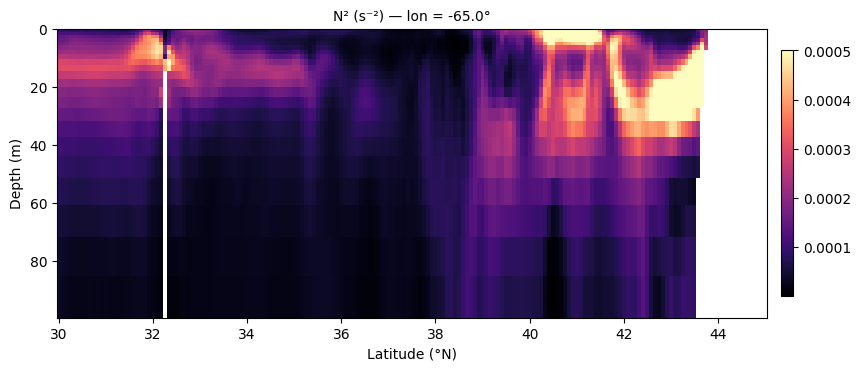

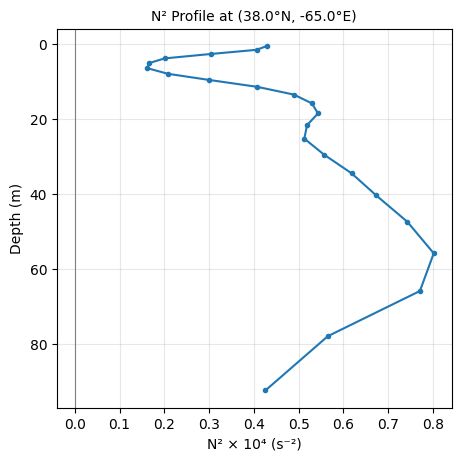

In [5]:
n2_op = BruntVaisalaFrequency(density="rho", depth="depth", rho0=rho0, positive="down")
ds_n2 = ds_rho.merge(n2_op(ds_rho), compat="no_conflicts")
profile_n2 = ds_n2.sel(lat=profile_lat, lon=profile_lon, method="nearest")

latdepth_section(ds_n2["n_squared"].clip(min=0, max=5e-4), title="N² (s⁻²)", cmap="magma")

fig, ax = plt.subplots(figsize=(4.5, 4.5), constrained_layout=True)
ax.plot(profile_n2["n_squared"].values * 1e4, profile_n2["depth"].values, marker="o", markersize=3)
ax.axvline(0, color="grey", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("N² × 10⁴ (s⁻²)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"N² Profile at ({profile_lat}°N, {profile_lon}°E)", fontsize=10)
ax.grid(alpha=0.3)
plt.show()

## 5 — Mixed-layer depth (MLD)

**ELI5.** Near the surface, wind and waves stir the ocean into a slab of nearly-uniform water. MLD is the depth where that slab ends — where the water suddenly becomes denser than the surface.

**What it is.** A scalar field (one number per `(time, lat, lon)`) marking the bottom of the surface mixed layer. The de Boyer Montégut threshold criterion is the operational standard: pick the shallowest depth where the local density exceeds the reference density (taken at 10 m to skip diurnal noise) by 0.03 kg/m³.

**Continuous formulation.**

$$
    \mathrm{MLD}(\lambda, \varphi) = \min\{ z > z_{\text{ref}} : \rho(z) - \rho(z_{\text{ref}}) > \Delta\rho_0 \},
$$

with $z_{\text{ref}} = 10$ m and $\Delta\rho_0 = 0.03$ kg/m³ by default.

**Discretisation.** `MixedLayerDepth(density="rho", depth="depth", reference_depth=10.0, threshold=0.03)` per-column linear-interpolates the reference-density crossing — accuracy is set by the vertical resolution of the input. With our 22-level cache, the depths range from ~0.5 m to ~92 m, so summer Gulf Stream MLDs (~10–30 m) are well-resolved; columns where MLD exceeds 92 m are returned as the bottom-depth (a fill convention to flag "search range exceeded").

**Interpretation.** In summer the Gulf Stream MLD is shallow (10–30 m) — the seasonal warming has built a strong, thin surface layer. In the GS frontal zone MLD bumps deeper because lateral stirring delays restratification. MLD anomalies feed directly into air-sea heat flux: a thinner mixed layer warms faster for the same surface flux and forms the upper limit on the heat budget reservoir.

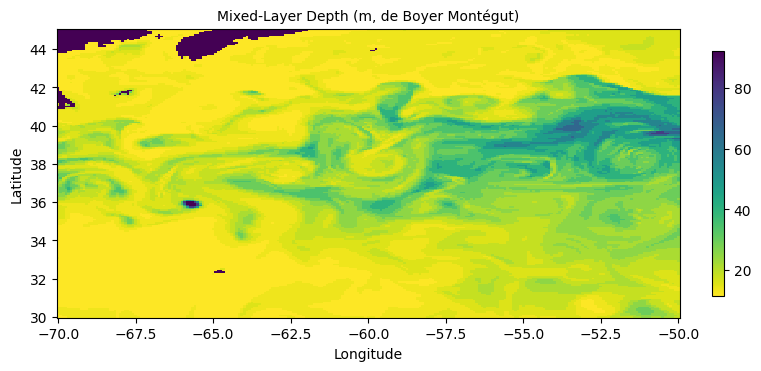

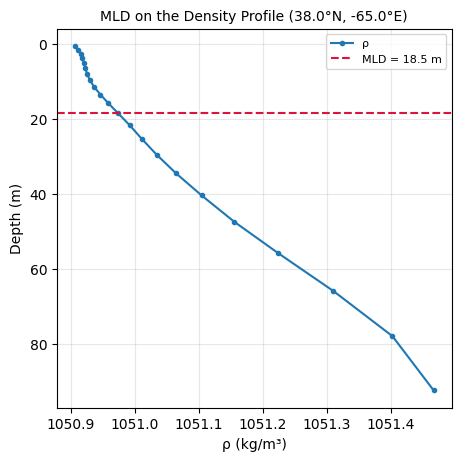

In [6]:
mld_op = MixedLayerDepth(density="rho", depth="depth", reference_depth=10.0, threshold=0.03)
mld = mld_op(ds_rho)["mld"]

surface_map(mld, title="Mixed-Layer Depth (m, de Boyer Montégut)", cmap="viridis_r")

# Profile + MLD overlay
fig, ax = plt.subplots(figsize=(4.5, 4.5), constrained_layout=True)
ax.plot(profile_rho["rho"].values, profile_rho["depth"].values, marker="o", markersize=3, color="tab:blue", label="ρ")
mld_here = float(mld.sel(lat=profile_lat, lon=profile_lon, method="nearest").values)
ax.axhline(mld_here, color="crimson", linewidth=1.5, linestyle="--", label=f"MLD = {mld_here:.1f} m")
ax.invert_yaxis()
ax.set_xlabel("ρ (kg/m³)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"MLD on the Density Profile ({profile_lat}°N, {profile_lon}°E)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 6 — Vertical lapse rate $\partial T / \partial z$

**ELI5.** How fast does temperature change as you go down? Big numbers near the thermocline; near zero in the mixed layer.

**What it is.** The vertical temperature gradient. In the atmosphere "lapse rate" usually means $-\partial T/\partial z$ (temperature decrease with altitude); in oceanography we keep the literal $\partial T / \partial z$ and let the sign carry the physical meaning. The mixed layer has $\partial T / \partial z \approx 0$ (well-mixed); the thermocline has the strongest gradient (typically $-0.1$ to $-1$ K/m for the seasonal thermocline).

**Continuous formulation.**

$$
    \Gamma_T(z) = \frac{\partial T}{\partial z}.
$$

**Discretisation.** `LapseRate(temperature="thetao", depth="depth", positive="down")` is central FD on the depth axis with the same `positive` convention as `BruntVaisalaFrequency`. With `positive="down"` and depth increasing downward, a warmer surface and cooler interior gives a *negative* lapse rate.

**Interpretation.** Lapse-rate maxima coincide with the seasonal thermocline (just below the mixed layer). The product is largely redundant with $N^2$ in regions where temperature dominates the density variation (most of the open ocean) and adds value primarily where salinity contributes meaningfully (estuaries, sea-ice melt zones, deep North Atlantic). Useful as a sanity check on the EOS choice — divergence between the lapse-rate-implied density gradient and the actual $\partial\rho/\partial z$ flags salinity contributions.

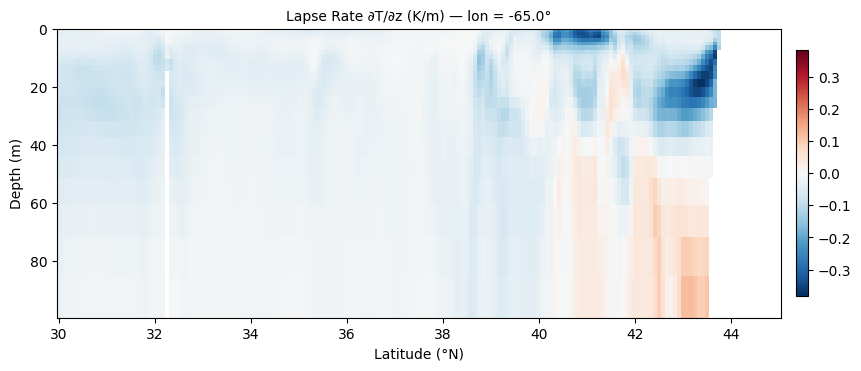

In [7]:
lapse_op = LapseRate(temperature="thetao", depth="depth", positive="down")
lapse = lapse_op(ds_t)["lapse_rate"]

latdepth_section(lapse, title="Lapse Rate ∂T/∂z (K/m)", cmap="RdBu_r", center_zero=True)

## 7 — Horizontal advection of $\theta$ by $(u, v)$

**ELI5.** Cold water flowing into a warm region cools it down (and vice versa). Advection tells you the rate of change of temperature at a point caused by water movement past it.

**What it is.** The horizontal advective tendency $\mathbf{u}_h \cdot \nabla_h \theta$ — the contribution of the flow to the local temperature time-rate-of-change. One term in the temperature budget, alongside vertical advection, diffusion, and surface fluxes. The sign convention: positive advection means *cold inflow* (the temperature is decreasing).

**Continuous formulation.**

$$
    \mathcal{A}_\theta = \mathbf{u}_h \cdot \nabla_h \theta = u\,\frac{\partial \theta}{\partial x} + v\,\frac{\partial \theta}{\partial y}.
$$

**Discretisation.** `Advection(scalar="thetao", components=("u","v"), dims=("lon","lat"))` runs the spherical-metric central-FD primitives on $\theta$ and combines them with the velocities pointwise. We compute on a single depth slice (the surface) — the operator is 2-D in spirit; vertical advection $w \partial\theta/\partial z$ is a separate diagnostic that needs $w$, which GLORYS does not ship in its public outputs.

**Interpretation.** Strong negative advection (warm-water inflow into cooler regions) marks the Gulf Stream's northward tongue along the eastern seaboard; sharp sign reversals at the front mark stirring filaments. This is the field that cooling/warming events propagate along — for instance, marine-heatwave detachment and recovery diagnostics use $\mathcal{A}_\theta$ as one of the candidate causes.

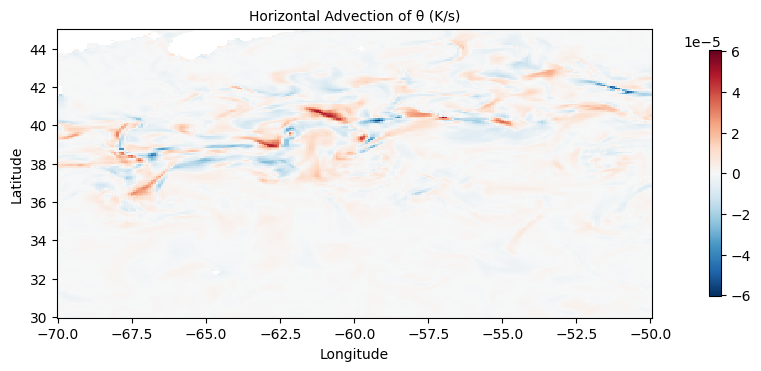

In [8]:
surf = ds_t.isel(depth=0).rename({"uo": "u", "vo": "v"})
adv_op = Advection(scalar="thetao", components=("u", "v"), dims=("lon", "lat"))
adv = adv_op(surf)["thetao_advection"]

surface_map(adv, title="Horizontal Advection of θ (K/s)", cmap="RdBu_r", center_zero=True)

## 8 — Barotropic potential vorticity

**ELI5.** Spinning water columns conserve a special quantity that tracks both their spin and how tall they are. Stretch the column and it spins faster; shrink it and it spins slower. Barotropic PV is that conservation law for a single-layer "shallow-water" ocean.

**What it is.** $q_b = (\zeta + f) / h$, the absolute vorticity divided by an effective layer thickness $h$. Conserved (in shallow-water with no friction or bottom topography variations) along trajectories. Generalises the rotation-stretching coupling that drives Rossby waves, topographic-wave dynamics, and isopycnal-following flow.

**Continuous formulation.**

$$
    q_b = \frac{\zeta + f}{h}, \qquad \zeta = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}.
$$

**Discretisation.** `PotentialVorticityBarotropic(height="h", u="u", v="v")` reuses the `RelativeVorticity` primitives on $(u, v)$, adds `coriolis_parameter(lat)` for $f$, and divides by $h$ pointwise. We construct $h = H_{\text{ref}} + \mathrm{SSH}$ with $H_{\text{ref}} = 1000$ m as a Gulf-Stream-relevant reference depth; the SSH perturbation is small (~1 m) compared to the reference, so the result is dominated by $(\zeta + f) / H_{\text{ref}}$. For a true layer-thickness in a multi-layer model, one would substitute the isopycnal-layer depth instead.

**Interpretation.** The bulk of the field is set by the planetary $f / H \sim 10^{-7}$ m⁻¹s⁻¹ in our domain — a smooth latitudinal gradient. The Gulf Stream front shows up as a thin band of enhanced PV (positive $\zeta$ on the cyclonic side); the SSH bumps shift PV by a few percent. Conservation of $q_b$ along streamlines is the dynamical reason mesoscale eddies tend to follow specific PV contours rather than crossing them — a common diagnostic in eddy-tracking work.

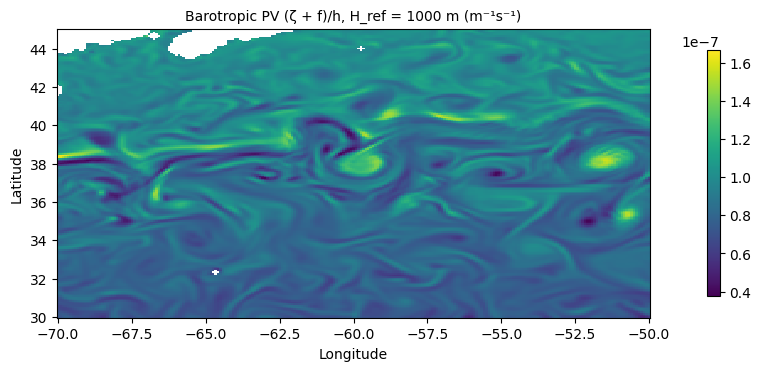

In [9]:
H_ref = 1000.0
ds_pv = surf.assign(h=H_ref + surf["zos"])
pv_op = PotentialVorticityBarotropic(height="h", u="u", v="v")
pv = pv_op(ds_pv)["pv_barotropic"]

surface_map(pv, title="Barotropic PV (ζ + f)/h, H_ref = 1000 m (m⁻¹s⁻¹)", cmap="viridis", center_zero=False)

## 9 — Bonus: a `Sequential` stratification pipeline

Each diagnostic above is a single-input `Operator` that *replaces* its input. To **augment** the GLORYS Dataset with derived columns (rather than chain-replacing them), wrap each in `xrtoolz.Augment` and chain them via `Sequential`. One call returns a Dataset with density, $N^2$, MLD, and lapse rate all merged in alongside the original `(zos, uo, vo, thetao, so)`.

Density itself is not yet a Layer-1 operator (it is a Tier-A function, `density_from_ts`, gated on the optional `gsw` dep), so we wrap the linear-EOS expression in a small inline `Operator` for the demo. A future PR can promote it.

In [10]:
from xrtoolz.core import Operator


class LinearDensity(Operator):
    """Linear-EOS in-situ density. Pedagogical fallback for `density_from_ts`."""

    def __init__(self, *, theta: str = "thetao", salinity: str = "so",
                 rho0: float = 1027.0, alpha: float = 2.0e-4, beta: float = 7.6e-4) -> None:
        self.theta = theta
        self.salinity = salinity
        self.rho0 = rho0
        self.alpha = alpha
        self.beta = beta

    def _apply(self, ds: xr.Dataset) -> xr.Dataset:
        rho = self.rho0 * (1 - self.alpha * ds[self.theta] + self.beta * ds[self.salinity])
        rho.attrs.update(long_name="In-situ density (linear EOS)", units="kg m-3")
        return xr.Dataset({"rho": rho})

    def get_config(self) -> dict[str, float | str]:
        return {"theta": self.theta, "salinity": self.salinity,
                "rho0": self.rho0, "alpha": self.alpha, "beta": self.beta}


stratification = Sequential(
    [
        Augment(LinearDensity()),
        Augment(BruntVaisalaFrequency(density="rho", depth="depth", rho0=rho0, positive="down")),
        Augment(MixedLayerDepth(density="rho", depth="depth", reference_depth=10.0, threshold=0.03)),
        Augment(LapseRate(temperature="thetao", depth="depth", positive="down")),
    ]
)
# Structure + per-step shape inference for the stratification chain.
print(stratification.describe())
print()
input_signature = Signature(
    dict(ds_t.sizes), dtype=str(ds_t["thetao"].dtype),
)
print(stratification.summary(input_signature))


Sequential (4 ops)
├── Augment(inner={'class': 'LinearDensity', 'config': {'theta': 'thetao', 'salinity': 'so', 'rho0': 1027.0, 'alpha': 0.0002, 'beta': 0.00076}})
├── Augment(inner={'class': 'BruntVaisalaFrequency', 'config': {'density': 'rho', 'depth': 'depth', 'rho0': 1027.0, 'g': None, 'positive': 'down'}})
├── Augment(inner={'class': 'MixedLayerDepth', 'config': {'density': 'rho', 'depth': 'depth', 'reference_depth': 10.0, 'threshold': 0.03}})
└── Augment(inner={'class': 'LapseRate', 'config': {'temperature': 'thetao', 'depth': 'depth', 'positive': 'down'}})

Sequential (4 ops)
Step  Operator                                                                                            Input Signature                              Output Signature                           
----  --------------------------------------------------------------------------------------------------  -------------------------------------------  -------------------------------------------
0     Augment(Linear

In [11]:
augmented = stratification(ds_t)
print("augmented columns:", list(augmented.data_vars))

augmented columns: ['uo', 'vo', 'thetao', 'so', 'zos', 'rho', 'n_squared', 'mld', 'lapse_rate']


## 10 — Bonus: full `Graph` DAG

The same diagnostics expressed as a DAG with one `Input(name='state')` and a terminal `Node` per diagnostic. Each output is independently addressable — convenient when downstream code wants the diagnostics as separate xr.Dataset objects (for panel plotting, for export, or for hand-off to a V6 capstone).

In [12]:
state = Input(name="state")
density_node = LinearDensity()(state)

scorecard = Graph(
    inputs={"state": state},
    outputs={
        "density": density_node,
        "lapse_rate": LapseRate(temperature="thetao", depth="depth", positive="down")(state),
    },
)
scorecard

Graph(inputs=['state'], outputs=['density', 'lapse_rate'])

In [13]:
out = scorecard(state=ds_t)
import pandas as pd

summary = pd.Series(
    {
        "density mean (kg/m³)": float(out["density"]["rho"].mean(skipna=True).values),
        "lapse rate mean (K/m)": float(out["lapse_rate"]["lapse_rate"].mean(skipna=True).values),
        "MLD basin-mean (m)": float(mld.mean(skipna=True).values),
        "N² basin-mean (s⁻²)": float(ds_n2["n_squared"].mean(skipna=True).values),
    },
    name="value",
).to_frame()
summary

,value
density mean (kg/m³),1051.013143
lapse rate mean (K/m),-0.032436
MLD basin-mean (m),20.603422
N² basin-mean (s⁻²),0.000103


## 11 — Takeaway

Stratification diagnostics in `xrtoolz.ocn` follow the same `(Dataset → Dataset)` contract as the kinematic ones, so they compose into the same `Sequential` and `Graph` machinery. The chief subtleties — sign convention on the depth axis, EOS choice (linear vs TEOS-10), reference-state for barotropic PV — are exposed as kwargs rather than baked in, so the same code drives both pedagogical demos and operational pipelines. Combined with the kinematic and along-track companion notebooks in this PR, the three together cover the headline `xrtoolz.ocn` API.

## 12 — Cache rebuild

See the V4 process-evaluation notebook for the `copernicusmarine` snippet that produces `glorys12_3d_gulfstream_2023-06.nc`.